Libraries
   ↓
Load Data
   ↓
Imbalance
   ↓
Models
   ↓
Cross Validation
   ↓
Model Comparison
   ↓
Optimization
   ↓
Evaluation
   ↓
Save Model

# ==============================
# 1. IMPORT LIBRARIES
# ==============================


In [67]:

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model Selection
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)

# Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Model Saving
import joblib

# Warnings
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [68]:


train_df = pd.read_parquet(r'M:\NT_PROJECT\train_encoded.parquet')
test_df = pd.read_parquet(r"M:\NT_PROJECT\test_encoded.parquet")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1037340, 76)
Test shape: (259335, 76)


In [69]:
X_train = train_df.drop(columns="is_fraud")
y_train = train_df["is_fraud"]

X_test = test_df.drop(columns="is_fraud")
y_test = test_df["is_fraud"]

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1037340, 75)
(1037340,)
(259335, 75)
(259335,)


# ==============================
# 3. IMBALANCE ANALYSIS
# ==============================
n froud-->?not froud 

In [70]:

# Calculate imbalance ratio
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()
print("\nNegative samples:", negative)
print("Positive samples:", positive)
imbalance_ratio = negative / positive
print("\nImbalance Ratio:", imbalance_ratio)


Negative samples: 1031335
Positive samples: 6005

Imbalance Ratio: 171.74604496253122


MODELS 

In [ ]:

from lightgbm import LGBMClassifier

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=imbalance_ratio,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=imbalance_ratio,
        random_state=42,
        n_jobs=-1,
        verbose=-1   # يمنع الطباعة الزيادة أثناء التدريب
    )
}

print("Models defined successfully!")

Models defined successfully!


# ==============================
# 5. STRATIFIED CROSS VALIDATION
# ==============================

In [ ]:


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

print("Cross Validation: 5 Stratified Folds")
print("Evaluation metrics:")
print(list(scoring.keys()))

Cross Validation: 5 Stratified Folds
Evaluation metrics:
['precision', 'recall', 'f1', 'roc_auc', 'pr_auc']


# ==============================
# 6. RUN CROSS VALIDATION FOR ALL MODELS
# ==============================

In [ ]:


import time

results = []

for name, model in models.items():

    print(f"Running: {name} ...")

    start_time = time.time()

    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=2
    )

    elapsed_time = time.time() - start_time

    results.append({
        "Model": name,
        "Precision": cv_results["test_precision"].mean(),
        "Recall": cv_results["test_recall"].mean(),
        "F1": cv_results["test_f1"].mean(),
        "ROC-AUC": cv_results["test_roc_auc"].mean(),
        "PR-AUC": cv_results["test_pr_auc"].mean(),
        "Training Time (s)": elapsed_time
    })

    print(f"✅ {name} done in {elapsed_time:.2f}s")



Running: Logistic Regression ...
✅ Logistic Regression done in 42.16s
Running: Decision Tree ...
✅ Decision Tree done in 96.12s
Running: Random Forest ...
✅ Random Forest done in 412.26s
Running: XGBoost ...
✅ XGBoost done in 67.35s
Running: LightGBM ...
✅ LightGBM done in 31.20s


In [ ]:

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="PR-AUC",
    ascending=False
).reset_index(drop=True)

print("\n=== Model Comparison ===")

display (comparison_df.round(4))



=== Model Comparison ===


,Model,Precision,Recall,F1,ROC-AUC,PR-AUC,Training Time (s)
0,XGBoost,0.2980,0.9690,0.4558,0.9982,0.9121,67.3525
1,Random Forest,0.9868,0.6981,0.8177,0.9872,0.9051,412.2583
2,Decision Tree,0.1420,0.9635,0.2475,0.9766,0.4728,96.1200
3,Logistic Regression,0.0367,0.7635,0.0701,0.9167,0.1686,42.1640
4,LightGBM,0.0938,0.9217,0.1702,0.9306,0.0958,31.2031


Optimization XGBOOST

In [ ]:

scoring = {
    "PR-AUC": "average_precision",
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1": "f1",
    "ROC-AUC": "roc_auc"
}



In [ ]:
# ==============================
# 8. FAST HYPERPARAMETER OPTIMIZATION — XGBoost (FIXED)
# ==============================

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
import time

param_distributions = {
    "n_estimators": randint(100, 400),
    "max_depth": randint(3, 8),
    "learning_rate": uniform(0.01, 0.29),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 6),
    "gamma": uniform(0, 0.4),
    "scale_pos_weight": [
        imbalance_ratio * 0.3,
        imbalance_ratio * 0.5,
        imbalance_ratio * 0.7,
        imbalance_ratio
    ]
}



xgb_base = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    n_jobs=1
)

cv_search = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,

    n_iter=8,

    scoring="average_precision",

    cv=cv_search,

    random_state=42,

  
    n_jobs=-1,

    verbose=2
)

start_time = time.time()

random_search.fit(
    X_train,
    y_train
)

elapsed_time = time.time() - start_time


Fitting 3 folds for each of 8 candidates, totalling 24 fits


In [ ]:

elapsed_time = time.time() - start_time

print(
    f" Optimization Time: "
    f"{elapsed_time:.2f} seconds "
    f"({elapsed_time / 60:.1f} minutes)"
)

print(
    f"\n Best PR-AUC: "
    f"{random_search.best_score_:.4f}"
)

print("\n Best Parameters:")

for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

best_xgb_model = random_search.best_estimator_

print("\n Best XGBoost model selected successfully")

 Optimization Time: 598.38 seconds (10.0 minutes)

 Best PR-AUC: 0.9475

 Best Parameters:
  colsample_bytree: 0.7700623497964979
  gamma: 0.08317666514727554
  learning_rate: 0.17463309506779753
  max_depth: 7
  min_child_weight: 2
  n_estimators: 317
  scale_pos_weight: 171.74604496253122
  subsample: 0.9757995766256756

 Best XGBoost model selected successfully


In [ ]:
# ==============================
# GET XGBOOST PROBABILITIES
# ==============================

y_prob = best_xgb_model.predict_proba(X_test)[:, 1]

print("y_prob created successfully")
print(y_prob[:10])

y_prob created successfully
[3.8011699e-06 4.8783971e-07 1.9664469e-06 6.4990277e-06 3.9224037e-06
 1.6949558e-07 1.0845793e-07 3.2215210e-06 4.7854642e-06 4.9328117e-04]


In [ ]:
# ==============================
# 10. THRESHOLD TUNING
# ==============================

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

# ترتيب النتائج حسب F1
threshold_df = threshold_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

print("=== Threshold Comparison ===")
display(threshold_df.round(4))

=== Threshold Comparison ===


,Threshold,Precision,Recall,F1
0,0.90,0.9581,0.8841,0.9196
1,0.85,0.9413,0.8974,0.9188
2,0.80,0.9271,0.9061,0.9164
3,0.75,0.9119,0.9167,0.9143
4,0.70,0.8971,0.9234,0.9100
5,0.65,0.8823,0.9287,0.9049
6,0.60,0.8620,0.9360,0.8975
7,0.55,0.8509,0.9427,0.8944
8,0.50,0.8356,0.9447,0.8868
9,0.45,0.8153,0.9467,0.8761


# ==============================
# THRESHOLD PERFORMANCE PLOT
# ==============================

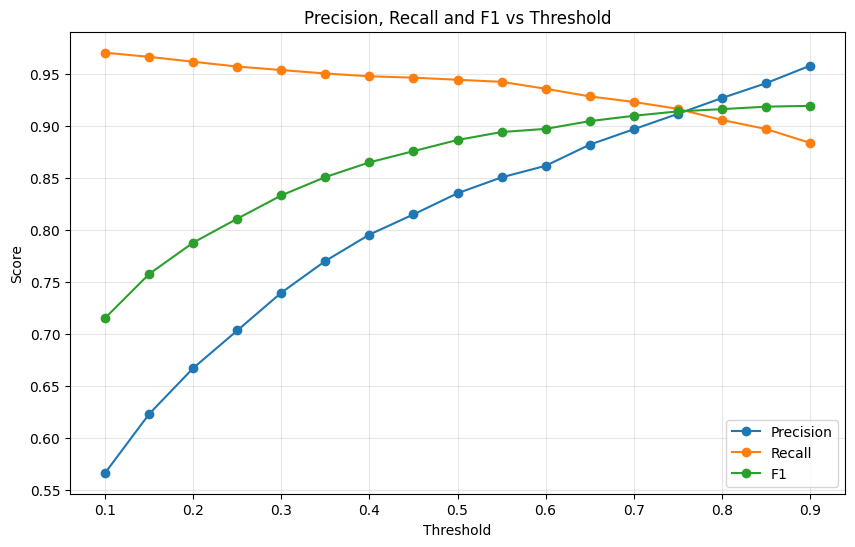

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 vs Threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# ==============================
# 11. FINAL THRESHOLD
# ==============================

In [ ]:


best_threshold = 0.85

final_pred = (y_prob >= best_threshold).astype(int)

print("Final Threshold:", best_threshold)

Final Threshold: 0.85


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

final_accuracy = accuracy_score(y_test, final_pred)

final_precision = precision_score(
    y_test,
    final_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_pred,
    zero_division=0
)

print("===================================")
print("FINAL XGBOOST PERFORMANCE")
print("===================================")

print(f"Threshold : {best_threshold}")
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")

FINAL XGBOOST PERFORMANCE
Threshold : 0.85
Accuracy  : 0.9991
Precision : 0.9413
Recall    : 0.8974
F1 Score  : 0.9188


-----------------------------------
pipline 
-----------------------------------

In [4]:
import pandas as pd
import numpy as np
import joblib

from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

In [42]:
DROP_COLS = [
    "Unnamed: 0",
    "trans_date_trans_time",
    "dob",
    "first",
    "last",
    "street",
    "city",
    "zip",
    "trans_num",
    "unix_time",

    # مش عايزين User يدخلهم ومش بنقدر نستنتجهم
    "cc_num",
    "lat",
    "long",
    "city_pop",
    "merch_lat",
    "merch_long"
]

ONEHOT_COLS = [
    "category",
    "state"
]

FREQUENCY_COLS = [
    "merchant",
    "job"
]

NUMERIC_COLS = [
    "amt",
    "trans_hour",
    "trans_day",
    "trans_month",
    "trans_dayofweek",
    "age"
]

In [43]:
def haversine(lat1, lon1, lat2, lon2):

    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        +
        np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return 6371 * c

In [59]:
class FeatureEngineeringTransformer(
    BaseEstimator,
    TransformerMixin
):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        df = X.copy()

        # Convert dates
        df["trans_date_trans_time"] = pd.to_datetime(
            df["trans_date_trans_time"]
        )

        df["dob"] = pd.to_datetime(
            df["dob"]
        )

        # Transaction time features
        df["trans_hour"] = (
            df["trans_date_trans_time"].dt.hour
        )

        df["trans_day"] = (
            df["trans_date_trans_time"].dt.day
        )

        df["trans_month"] = (
            df["trans_date_trans_time"].dt.month
        )

        df["trans_dayofweek"] = (
            df["trans_date_trans_time"].dt.dayofweek
        )

        # Customer age
        df["age"] = (
            (
                df["trans_date_trans_time"]
                - df["dob"]
            ).dt.days / 365.25
        ).astype(int)

        return df

In [9]:
class DropColumnsTransformer(
    BaseEstimator,
    TransformerMixin
):

    def __init__(self, columns=None):
        self.columns = (
            columns if columns is not None
            else DROP_COLS
        )

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        return X.drop(
            columns=self.columns,
            errors="ignore"
        )

In [47]:
class GenderEncoder(
    BaseEstimator,
    TransformerMixin
):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        df = X.copy()

        df["gender"] = (
            df["gender"]
            .map({
                "F": 0,
                "M": 1
            })
            .fillna(-1)
            .astype(int)
        )

        return df

In [49]:
class FrequencyEncoder(
    BaseEstimator,
    TransformerMixin
):

    def __init__(self, columns=None):
        self.columns = (
            columns if columns is not None
            else FREQUENCY_COLS
        )

    def fit(self, X, y=None):

        self.frequency_maps_ = {}

        for col in self.columns:

            self.frequency_maps_[col] = (
                X[col]
                .value_counts(normalize=True)
            )

        return self

    def transform(self, X):

        df = X.copy()

        for col in self.columns:

            df[col + "_freq"] = (
                df[col]
                .map(self.frequency_maps_[col])
                .fillna(0)
            )

        return df

In [50]:
class FinalPreprocessor(
    BaseEstimator,
    TransformerMixin
):

    def __init__(
        self,
        numeric_cols=None,
        onehot_cols=None
    ):

        self.numeric_cols = (
            numeric_cols if numeric_cols is not None
            else NUMERIC_COLS
        )

        self.onehot_cols = (
            onehot_cols if onehot_cols is not None
            else ONEHOT_COLS
        )

    def fit(self, X, y=None):

        self.ohe_ = OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )

        self.ohe_.fit(
            X[self.onehot_cols]
        )

        return self

    def transform(self, X):

        df = X.copy()

        ohe_data = self.ohe_.transform(
            df[self.onehot_cols]
        )

        ohe_columns = (
            self.ohe_
            .get_feature_names_out(
                self.onehot_cols
            )
        )

        ohe_df = pd.DataFrame(
            ohe_data,
            columns=ohe_columns,
            index=df.index
        )

        final_df = pd.concat(
            [
                df[
                    self.numeric_cols
                    + [
                        "gender",
                        "merchant_freq",
                        "job_freq"
                    ]
                ],
                ohe_df
            ],
            axis=1
        )

        return final_df

In [51]:
class ThresholdClassifier(
    BaseEstimator,
    ClassifierMixin
):

    def __init__(
        self,
        model,
        threshold=0.85
    ):

        self.model = model
        self.threshold = threshold

    def fit(self, X, y):

        self.model.fit(X, y)

        self.classes_ = self.model.classes_

        return self

    def predict_proba(self, X):

        return self.model.predict_proba(X)

    def predict(self, X):

        probabilities = (
            self.model
            .predict_proba(X)[:, 1]
        )

        return (
            probabilities >= self.threshold
        ).astype(int)

    def get_feature_importances(self):

        return self.model.feature_importances_

In [52]:
BEST_PARAMS = {
    "n_estimators": 317,
    "max_depth": 7,
    "learning_rate": 0.17463309506779753,
    "subsample": 0.9757995766256756,
    "colsample_bytree": 0.7700623497964979,
    "min_child_weight": 2,
    "gamma": 0.08317666514727554,
    "scale_pos_weight": 171.74604496253122,
}

BEST_THRESHOLD = 0.85

In [15]:
raw_train = pd.read_csv(
    r"M:\data_set\fraudTrain.csv"
)

X_raw = raw_train.drop(
    columns="is_fraud"
)

y_raw = raw_train["is_fraud"]

print("X_raw:", X_raw.shape)
print("y_raw:", y_raw.shape)

X_raw: (1296675, 22)
y_raw: (1296675,)


In [16]:
xgb_final = XGBClassifier(
    **BEST_PARAMS,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

print(type(xgb_final))
print(xgb_final)

<class 'xgboost.sklearn.XGBClassifier'>
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7700623497964979, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=0.08317666514727554, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.17463309506779753,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=317, n_jobs=-1,
              num_parallel_tree=None, ...)


In [53]:
fraud_pipeline = Pipeline([
    
    (
        "feature_engineering",
        FeatureEngineeringTransformer()
    ),

    (
        "drop_columns",
        DropColumnsTransformer(
            columns=DROP_COLS
        )
    ),

    (
        "gender_encoding",
        GenderEncoder()
    ),

    (
        "frequency_encoding",
        FrequencyEncoder(
            columns=FREQUENCY_COLS
        )
    ),

    (
        "preprocessing",
        FinalPreprocessor(
            numeric_cols=NUMERIC_COLS,
            onehot_cols=ONEHOT_COLS
        )
    ),

    (
        "model",
        ThresholdClassifier(
            model=xgb_final,
            threshold=BEST_THRESHOLD
        )
    )
])

print(fraud_pipeline)
print(type(fraud_pipeline))

Pipeline(steps=[('feature_engineering', FeatureEngineeringTransformer()),
                ('drop_columns',
                 DropColumnsTransformer(columns=['Unnamed: 0',
                                                 'trans_date_trans_time', 'dob',
                                                 'first', 'last', 'street',
                                                 'city', 'zip', 'trans_num',
                                                 'unix_time', 'cc_num', 'lat',
                                                 'long', 'city_pop',
                                                 'merch_lat', 'merch_long'])),
                ('gender_encoding', GenderEncoder()),
                ('frequency_encoding',
                 Frequenc...
                                                         gamma=0.08317666514727554,
                                                         grow_policy=None,
                                                         importance_type=None,
         

In [54]:
model = fraud_pipeline

print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [55]:
import os

print(os.path.exists(
    r"M:\NT_PROJECT\afrip_fraud_pipeline.pkl"
))

True


In [56]:
# Fit the complete pipeline
fraud_pipeline.fit(X_raw, y_raw)

print("Pipeline fitted successfully!")

Pipeline fitted successfully!


In [28]:
print(type(fraud_pipeline))

<class 'sklearn.pipeline.Pipeline'>


In [64]:
# =========================================================
# AFRIP - COMPLETE FRAUD PIPELINE
# =========================================================

import pandas as pd
import numpy as np
import joblib

from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier


# =========================================================
# 1. CONFIGURATION
# =========================================================

DROP_COLS = [
    "Unnamed: 0",
    "trans_date_trans_time",
    "dob",
    "first",
    "last",
    "street",
    "city",
    "zip",
    "trans_num",
    "unix_time",

    # Features unavailable from user input
    "cc_num",
    "lat",
    "long",
    "city_pop",
    "merch_lat",
    "merch_long"
]


ONEHOT_COLS = [
    "category",
    "state"
]


FREQUENCY_COLS = [
    "merchant",
    "job"
]


NUMERIC_COLS = [
    "amt",
    "trans_hour",
    "trans_day",
    "trans_month",
    "trans_dayofweek",
    "age"
]


BEST_PARAMS = {
    "n_estimators": 317,
    "max_depth": 7,
    "learning_rate": 0.17463309506779753,
    "subsample": 0.9757995766256756,
    "colsample_bytree": 0.7700623497964979,
    "min_child_weight": 2,
    "gamma": 0.08317666514727554,
    "scale_pos_weight": 171.74604496253122
}


BEST_THRESHOLD = 0.85


# =========================================================
# 2. FEATURE ENGINEERING
# =========================================================

class FeatureEngineeringTransformer(
    BaseEstimator,
    TransformerMixin
):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        df = X.copy()

        # Convert dates
        df["trans_date_trans_time"] = pd.to_datetime(
            df["trans_date_trans_time"]
        )

        df["dob"] = pd.to_datetime(
            df["dob"]
        )

        # -----------------------------
        # Transaction time features
        # -----------------------------

        df["trans_hour"] = (
            df["trans_date_trans_time"].dt.hour
        )

        df["trans_day"] = (
            df["trans_date_trans_time"].dt.day
        )

        df["trans_month"] = (
            df["trans_date_trans_time"].dt.month
        )

        df["trans_dayofweek"] = (
            df["trans_date_trans_time"].dt.dayofweek
        )

        # -----------------------------
        # Customer age
        # -----------------------------

        df["age"] = (
            (
                df["trans_date_trans_time"]
                - df["dob"]
            ).dt.days / 365.25
        ).astype(int)

        return df


# =========================================================
# 3. DROP COLUMNS
# =========================================================

class DropColumnsTransformer(
    BaseEstimator,
    TransformerMixin
):

    def __init__(self, columns=None):
        self.columns = (
            columns if columns is not None
            else DROP_COLS
        )

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        return X.drop(
            columns=self.columns,
            errors="ignore"
        )


# =========================================================
# 4. GENDER ENCODING
# =========================================================

class GenderEncoder(
    BaseEstimator,
    TransformerMixin
):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        df = X.copy()

        df["gender"] = (
            df["gender"]
            .map({
                "F": 0,
                "M": 1
            })
            .fillna(-1)
            .astype(int)
        )

        return df


# =========================================================
# 5. FREQUENCY ENCODING
# =========================================================

class FrequencyEncoder(
    BaseEstimator,
    TransformerMixin
):

    def __init__(self, columns=None):
        self.columns = (
            columns if columns is not None
            else FREQUENCY_COLS
        )

    def fit(self, X, y=None):

        self.frequency_maps_ = {}

        for col in self.columns:

            self.frequency_maps_[col] = (
                X[col]
                .value_counts(normalize=True)
            )

        return self

    def transform(self, X):

        df = X.copy()

        for col in self.columns:

            df[col + "_freq"] = (
                df[col]
                .map(self.frequency_maps_[col])
                .fillna(0)
            )

        return df


# =========================================================
# 6. FINAL PREPROCESSOR
# =========================================================

class FinalPreprocessor(
    BaseEstimator,
    TransformerMixin
):

    def __init__(
        self,
        numeric_cols=None,
        onehot_cols=None
    ):

        self.numeric_cols = (
            numeric_cols if numeric_cols is not None
            else NUMERIC_COLS
        )

        self.onehot_cols = (
            onehot_cols if onehot_cols is not None
            else ONEHOT_COLS
        )

    def fit(self, X, y=None):

        self.ohe_ = OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )

        self.ohe_.fit(
            X[self.onehot_cols]
        )

        return self

    def transform(self, X):

        df = X.copy()

        # One-Hot Encoding
        ohe_data = self.ohe_.transform(
            df[self.onehot_cols]
        )

        ohe_columns = (
            self.ohe_
            .get_feature_names_out(
                self.onehot_cols
            )
        )

        ohe_df = pd.DataFrame(
            ohe_data,
            columns=ohe_columns,
            index=df.index
        )

        # Final features
        final_df = pd.concat(
            [
                df[
                    self.numeric_cols
                    + [
                        "gender",
                        "merchant_freq",
                        "job_freq"
                    ]
                ],
                ohe_df
            ],
            axis=1
        )

        return final_df


# =========================================================
# 7. THRESHOLD CLASSIFIER
# =========================================================

class ThresholdClassifier(
    BaseEstimator,
    ClassifierMixin
):

    def __init__(
        self,
        model,
        threshold=0.85
    ):

        self.model = model
        self.threshold = threshold

    def fit(self, X, y):

        self.model.fit(X, y)

        self.classes_ = self.model.classes_

        return self

    def predict_proba(self, X):

        return self.model.predict_proba(X)

    def predict(self, X):

        probabilities = (
            self.model
            .predict_proba(X)[:, 1]
        )

        return (
            probabilities >= self.threshold
        ).astype(int)

    def get_feature_importances(self):

        return self.model.feature_importances_


# =========================================================
# 8. LOAD RAW DATA
# =========================================================

raw_train = pd.read_csv(
    r"M:\data_set\fraudTrain.csv"
)

X_raw = raw_train.drop(
    columns="is_fraud"
)

y_raw = raw_train["is_fraud"]

print("Raw data:")
print("X:", X_raw.shape)
print("y:", y_raw.shape)


# =========================================================
# 9. CREATE XGBOOST MODEL
# =========================================================

xgb_final = XGBClassifier(
    **BEST_PARAMS,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

print("\nXGBoost created:")
print(type(xgb_final))


# =========================================================
# 10. CREATE COMPLETE PIPELINE
# =========================================================

fraud_pipeline = Pipeline([

    (
        "feature_engineering",
        FeatureEngineeringTransformer()
    ),

    (
        "drop_columns",
        DropColumnsTransformer(
            columns=DROP_COLS
        )
    ),

    (
        "gender_encoding",
        GenderEncoder()
    ),

    (
        "frequency_encoding",
        FrequencyEncoder(
            columns=FREQUENCY_COLS
        )
    ),

    (
        "preprocessing",
        FinalPreprocessor(
            numeric_cols=NUMERIC_COLS,
            onehot_cols=ONEHOT_COLS
        )
    ),

    (
        "model",
        ThresholdClassifier(
            model=xgb_final,
            threshold=BEST_THRESHOLD
        )
    )

])


print("\n===================================")
print("PIPELINE CREATED")
print("===================================")

print(fraud_pipeline)

print("\nPipeline type:")
print(type(fraud_pipeline))


# =========================================================
# 11. FIT PIPELINE
# =========================================================

print("\nTraining pipeline...")

fraud_pipeline.fit(
    X_raw,
    y_raw
)

print("\n===================================")
print("PIPELINE FITTED SUCCESSFULLY")
print("===================================")




Raw data:
X: (1296675, 22)
y: (1296675,)

XGBoost created:
<class 'xgboost.sklearn.XGBClassifier'>

PIPELINE CREATED
Pipeline(steps=[('feature_engineering', FeatureEngineeringTransformer()),
                ('drop_columns',
                 DropColumnsTransformer(columns=['Unnamed: 0',
                                                 'trans_date_trans_time', 'dob',
                                                 'first', 'last', 'street',
                                                 'city', 'zip', 'trans_num',
                                                 'unix_time', 'cc_num', 'lat',
                                                 'long', 'city_pop',
                                                 'merch_lat', 'merch_long'])),
                ('gender_encoding', GenderEncoder()),
                ('frequency_encoding',
                 Frequenc...
                                                         gamma=0.08317666514727554,
                                              

In [63]:
pipeline_path = r"M:\NT_PROJECT\afrip_fraud_pipeline.pkl"

joblib.dump(
    fraud_pipeline,
    pipeline_path
)

print("Pipeline saved successfully!")
print("Path:", pipeline_path)
print("Type:", type(fraud_pipeline))

Pipeline saved successfully!
Path: M:\NT_PROJECT\afrip_fraud_pipeline.pkl
Type: <class 'sklearn.pipeline.Pipeline'>


In [65]:
user_input = pd.DataFrame([{
    "amt": 350.75,
    "category": "shopping_net",
    "merchant": "merchant_example",
    "gender": "M",
    "job": "Software Engineer",
    "state": "NY",
    "trans_date_trans_time": "2026-08-12 14:30:00",
    "dob": "1998-05-20"
}])
display(user_input)

,amt,category,merchant,gender,job,state,trans_date_trans_time,dob
0,350.75,shopping_net,merchant_example,M,Software Engineer,NY,2026-08-12 14:30:00,1998-05-20


In [66]:
# ==========================================
# TEST PIPELINE WITH USER INPUT
# ==========================================

prediction = fraud_pipeline.predict(user_input)[0]

fraud_probability = fraud_pipeline.predict_proba(
    user_input
)[0, 1]

print("===================================")
print("AFRIP FRAUD DETECTION")
print("===================================")

print(
    "Fraud Probability:",
    round(fraud_probability * 100, 2),
    "%"
)

print(
    "Prediction:",
    prediction
)

print(
    "Decision:",
    "BLOCK" if prediction == 1 else "ALLOW"
)

AFRIP FRAUD DETECTION
Fraud Probability: 0.04 %
Prediction: 0
Decision: ALLOW
